
Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [48]:
## library imports here
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [3]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")

In [5]:
ha.head()

,age,sex,cp,trtbps,chol,restecg,thalach,output
0,63,1,3,145,233,0,150,1
1,37,1,2,130,250,1,187,1
2,56,1,1,120,236,1,178,1
3,57,0,0,120,354,1,163,1
4,57,1,0,140,192,1,148,1


In [20]:
X = ha.drop(['cp', 'output'], axis = 1)
y = ha['cp']

In [21]:
X.head()

,age,sex,trtbps,chol,restecg,thalach
0,63,1,145,233,0,150
1,37,1,130,250,1,187
2,56,1,120,236,1,178
3,57,0,120,354,1,163
4,57,1,140,192,1,148


In [22]:
y.head()

,cp
0,3
1,2
2,1
3,0
4,0


## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


In [32]:
dummify_stdz = ColumnTransformer([
    ("dummify", OneHotEncoder(sparse_output = False), ['restecg']),
    ("scale", StandardScaler(), ['age','trtbps','chol','thalach'])
    ],
    remainder="passthrough"
).set_output(transform = "pandas")

dummify_stdz.fit_transform(X)

,dummify__restecg_0,dummify__restecg_1,dummify__restecg_2,scale__age,scale__trtbps,scale__chol,scale__thalach,remainder__sex
0,1.0,0.0,0.0,0.945954,0.730199,-0.264149,0.023843,1
1,0.0,1.0,0.0,-1.896714,-0.118797,0.059825,1.618801,1
2,0.0,1.0,0.0,0.180620,-0.684795,-0.206978,1.230838,1
3,0.0,1.0,0.0,0.289954,-0.684795,2.041783,0.584234,0
4,0.0,1.0,0.0,0.289954,0.447201,-1.045498,-0.062371,1
...,...,...,...,...,...,...,...,...
268,1.0,0.0,0.0,0.508621,1.805595,-1.350415,-2.562575,1
269,0.0,1.0,0.0,0.289954,0.447201,-0.111691,-1.140045,0
270,0.0,1.0,0.0,-1.022047,-1.250793,0.326627,-0.752082,1
271,0.0,1.0,0.0,1.492621,0.673600,-1.026441,-0.364120,1


In [33]:
dummify = ColumnTransformer([
    ("dummify", OneHotEncoder(sparse_output = False), ['restecg']),
    ],
    remainder="passthrough"
).set_output(transform = "pandas")

dummify.fit_transform(X)

,dummify__restecg_0,dummify__restecg_1,dummify__restecg_2,remainder__age,remainder__sex,remainder__trtbps,remainder__chol,remainder__thalach
0,1.0,0.0,0.0,63,1,145,233,150
1,0.0,1.0,0.0,37,1,130,250,187
2,0.0,1.0,0.0,56,1,120,236,178
3,0.0,1.0,0.0,57,0,120,354,163
4,0.0,1.0,0.0,57,1,140,192,148
...,...,...,...,...,...,...,...,...
268,1.0,0.0,0.0,59,1,164,176,90
269,0.0,1.0,0.0,57,0,140,241,123
270,0.0,1.0,0.0,45,1,110,264,132
271,0.0,1.0,0.0,68,1,144,193,141


In [34]:
#KNN model
KNN_pipeline = Pipeline(
    [
        ("preprocessing", dummify_stdz),
        ("knn", KNeighborsClassifier(n_neighbors = 3))
    ]
)

KNN_pipeline.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('knn', KNeighborsClassifier(n_neighbors=3))])

In [35]:
#KNN metrics

#overall accuracy
accuracy_KNN = cross_val_score(KNN_pipeline, X, y, cv = 10, scoring = "accuracy").mean()

#average f1 across all categories
f1_macro_KNN = cross_val_score(KNN_pipeline, X, y, cv = 10, scoring = "f1_macro").mean()

accuracy_KNN, f1_macro_KNN

(np.float64(0.42208994708994707), np.float64(0.23575645391415842))

In [44]:
#decision tree model
dt_pipeline = Pipeline(
    [
        ("preprocessing", dummify),
        ("dt", DecisionTreeClassifier(max_depth = 2))
    ]
)

dt_final = dt_pipeline.fit(X, y)

[Text(0.5, 0.8333333333333334, 'remainder__thalach <= 144.5\ngini = 0.661\nsamples = 273\nvalue = [128, 44, 81, 20]'),
 Text(0.25, 0.5, 'remainder__age <= 72.5\ngini = 0.455\nsamples = 105\nvalue = [75, 9, 17, 4]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.438\nsamples = 103\nvalue = [75.0, 8.0, 16.0, 4.0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.5\nsamples = 2\nvalue = [0, 1, 1, 0]'),
 Text(0.75, 0.5, 'remainder__thalach <= 161.5\ngini = 0.703\nsamples = 168\nvalue = [53, 35, 64, 16]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.637\nsamples = 72\nvalue = [32, 6, 28, 6]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.709\nsamples = 96\nvalue = [21, 29, 36, 10]')]

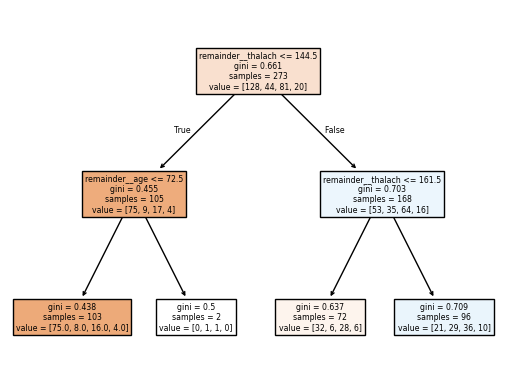

In [45]:
#plot decision tree
plot_tree(dt_pipeline.named_steps["dt"], feature_names=dt_pipeline.named_steps["preprocessing"].get_feature_names_out(input_features=getattr(X, "columns", None)), filled=True)

In [46]:
print(dt_final.classes_)

[0 1 2 3]


The decision tree starts with split one, which uses maximum heart rate achieved during exercise <= 144.5 and > 144.5 BPM to split the data with 273 training observations total. Those who satisfy the max BPM <= 144.5 requirement (105 observations) are then split by age <= 72.5 or > 72.5. Those <= 72.5 years old are primarily identified as chest paint type 0 = asymptomatic. Those > 72.5 years old are primarily identified as chest paint type 1 = typical angina and 2 = atypical angina. Those who satisfy the max BPM > 144.5 requirement (168 observations) are split into two max BPM groups again, <= 161.5 or > 161.5. Those with max BPM <= 161.5 are primarily identified as chest paint type 2 = atypical angina. Those with max BPM > 161.5 are primarily identified as chest paint type 2 as well = atypical angina.

In [47]:
#dt metrics

#overall accuracy
accuracy_dt = cross_val_score(dt_pipeline, X, y, cv = 10, scoring = "accuracy").mean()

#average f1 across all categories
f1_macro_dt = cross_val_score(dt_pipeline, X, y, cv = 10, scoring = "f1_macro").mean()

accuracy_dt, f1_macro_dt

(np.float64(0.4838624338624339), np.float64(0.24971168660659418))

In [53]:
#LDA model
lda_pipeline = Pipeline([
    ("preprocessing", dummify_stdz),
    ("lda", LinearDiscriminantAnalysis())
])

lda_pipeline.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('lda', LinearDiscriminantAnalysis())])

In [54]:
#LDA metrics

#overall accuracy
accuracy_lda = cross_val_score(lda_pipeline, X, y, cv = 10, scoring = "accuracy").mean()

#average f1 across all categories
f1_macro_lda = cross_val_score(lda_pipeline, X, y, cv = 10, scoring = "f1_macro").mean()

accuracy_lda, f1_macro_lda

(np.float64(0.46296296296296297), np.float64(0.24641696421422724))

## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

In [57]:
#create new columns for cp category
ha['cp_is_3'] = (ha['cp']==3)*1
ha['cp_is_2'] = (ha['cp']==2)*1
ha['cp_is_1'] = (ha['cp']==1)*1
ha['cp_is_0'] = (ha['cp']==0)*1
ha.head()

,age,sex,cp,trtbps,chol,restecg,thalach,output,cp_is_3,cp_is_2,cp_is_1,cp_is_0
0,63,1,3,145,233,0,150,1,1,0,0,0
1,37,1,2,130,250,1,187,1,0,1,0,0
2,56,1,1,120,236,1,178,1,0,0,1,0
3,57,0,0,120,354,1,163,1,0,0,0,1
4,57,1,0,140,192,1,148,1,0,0,0,1


In [60]:
logit_dummify_stdz = ColumnTransformer([
    ("dummify", OneHotEncoder(sparse_output = False, drop = "first"), ['restecg']),
    ("scale", StandardScaler(), ['age','trtbps','chol','thalach'])
    ],
    remainder="passthrough"
).set_output(transform = "pandas")

logit_dummify_stdz.fit_transform(X)

,dummify__restecg_1,dummify__restecg_2,scale__age,scale__trtbps,scale__chol,scale__thalach,remainder__sex
0,0.0,0.0,0.945954,0.730199,-0.264149,0.023843,1
1,1.0,0.0,-1.896714,-0.118797,0.059825,1.618801,1
2,1.0,0.0,0.180620,-0.684795,-0.206978,1.230838,1
3,1.0,0.0,0.289954,-0.684795,2.041783,0.584234,0
4,1.0,0.0,0.289954,0.447201,-1.045498,-0.062371,1
...,...,...,...,...,...,...,...
268,0.0,0.0,0.508621,1.805595,-1.350415,-2.562575,1
269,1.0,0.0,0.289954,0.447201,-0.111691,-1.140045,0
270,1.0,0.0,-1.022047,-1.250793,0.326627,-0.752082,1
271,1.0,0.0,1.492621,0.673600,-1.026441,-0.364120,1


In [63]:
#chest pain type = 3 logistic model
X = ha[['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach']]
y = ha['cp_is_3']

logit_cp3_pipeline = Pipeline(
    [
     ("preprocessing", logit_dummify_stdz),
     ("logit", LogisticRegression())
    ]
)

logit_cp3_pipeline.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logit', LogisticRegression())])

In [69]:
#f1 score
f1_logit_cp3 = cross_val_score(logit_cp3_pipeline, X, y, cv = 10, scoring = "f1").mean()
f1_logit_cp3

np.float64(0.0)

In [66]:
#chest pain type = 2 logistic model
X = ha[['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach']]
y = ha['cp_is_2']

logit_cp2_pipeline = Pipeline(
    [
     ("preprocessing", logit_dummify_stdz),
     ("logit", LogisticRegression())
    ]
)

logit_cp2_pipeline.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logit', LogisticRegression())])

In [70]:
#f1 score
f1_logit_cp2 = cross_val_score(logit_cp2_pipeline, X, y, cv = 10, scoring = "f1").mean()
f1_logit_cp2

np.float64(0.0)

In [71]:
#chest pain type = 1 logistic model
X = ha[['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach']]
y = ha['cp_is_1']

logit_cp1_pipeline = Pipeline(
    [
     ("preprocessing", logit_dummify_stdz),
     ("logit", LogisticRegression())
    ]
)

logit_cp1_pipeline.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logit', LogisticRegression())])

In [72]:
#f1 score
f1_logit_cp1 = cross_val_score(logit_cp1_pipeline, X, y, cv = 10, scoring = "f1").mean()
f1_logit_cp1

np.float64(0.0)

In [73]:
#chest pain type = 0 logistic model
X = ha[['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach']]
y = ha['cp_is_0']

logit_cp0_pipeline = Pipeline(
    [
     ("preprocessing", logit_dummify_stdz),
     ("logit", LogisticRegression())
    ]
)

logit_cp0_pipeline.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logit', LogisticRegression())])

In [74]:
#f1 score
f1_logit_cp0 = cross_val_score(logit_cp0_pipeline, X, y, cv = 10, scoring = "f1").mean()
f1_logit_cp0

np.float64(0.5967554628634573)

OvR was best at distinguishing the chest pain type = 0 (asymptomatic) category due to having the largest F1 score.

## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

In [80]:
#cp 0 vs. 1
ha_01 = ha[(ha["cp"] == 0) | (ha["cp"] == 1)]

X = ha_01[['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach']]
y = ha_01["cp"]

logit_ovo_pipeline = Pipeline(
    [
        ("preprocessing", logit_dummify_stdz),
        ("logit", LogisticRegression())
    ]
)

logit_ovo_pipeline.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logit', LogisticRegression())])

In [81]:
logit_ovo_rocauc = cross_val_score(logit_ovo_pipeline, X, y, cv = 10, scoring = "roc_auc").mean()
logit_ovo_rocauc

np.float64(0.7688461538461538)

In [82]:
#cp 0 vs. 2
ha_02 = ha[(ha["cp"] == 0) | (ha["cp"] == 2)]

X = ha_02[['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach']]
y = ha_02["cp"]

logit_ovo_pipeline2 = Pipeline(
    [
        ("preprocessing", logit_dummify_stdz),
        ("logit", LogisticRegression())
    ]
)

logit_ovo_pipeline2.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logit', LogisticRegression())])

In [83]:
logit_ovo_rocauc2 = cross_val_score(logit_ovo_pipeline2, X, y, cv = 10, scoring = "roc_auc").mean()
logit_ovo_rocauc2

np.float64(0.6583956552706554)

In [84]:
#cp 0 vs. 3
ha_03 = ha[(ha["cp"] == 0) | (ha["cp"] == 3)]

X = ha_03[['age', 'sex', 'trtbps', 'chol', 'restecg', 'thalach']]
y = ha_03["cp"]

logit_ovo_pipeline3 = Pipeline(
    [
        ("preprocessing", logit_dummify_stdz),
        ("logit", LogisticRegression())
    ]
)

logit_ovo_pipeline3.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['restecg']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'trtbps', 'chol',
                                                   'thalach'])])),
                ('logit', LogisticRegression())])

In [85]:
logit_ovo_rocauc3 = cross_val_score(logit_ovo_pipeline3, X, y, cv = 10, scoring = "roc_auc").mean()
logit_ovo_rocauc3

np.float64(0.7125)

The OVO for chest pain type 0 = asymptomatic vs. 1 = typical angina performed the best due to having the largest AUC score.